In [2]:
import numpy as np
from scipy.integrate import odeint,solve_ivp
import matplotlib.pyplot as plt
from scipy import interpolate
from functools import partial
import matplotlib
from numpy import exp
import pandas as pd
%matplotlib inline
from ipywidgets import interact
import math

In [3]:
###Comparing pituitary dividing vs. nondividing:

In [4]:
##Model A:
#Simulating for pituitary dividing:

In [5]:
def get5eqsparams(timescale='day'):
    #parameters are from the paper Mathematical modeling of the hypothalamic-pituitary-adrenal gland (HPA) axis, including hippocampal mechanisms.
    #Andersen M1, Vinther F, Ottesen JT.
    
    a1=1/5 #[1/min]
    a2=1/30 #[1/min]
    a3=1/90 #[1/min]

    #mitosis every ** days according to Nolan et al    
    aP=1/15/(60*24)
    
    # turnover of ** days according to Kataoka et al
    aA=1/15/(60*24)

    
    #We normalize all means to 1, we therefore get
    b1=a1;b2=a2;b3=a3;bA=aA;bP=aP;
    
    res=np.array([a1,a2,a3,aA,aP,b1,b2,b3,bA,bP])
    
    if timescale=='hour':
        res=60*res
    elif timescale=='day':
        res=24*60*res
    else:
        raise ValueError('timescale {} is not defined'.format(timescale))
    
    return res


def HPA_model_simulation_o_pituitary_dividing(y,t,timescale='day',u_func = lambda t:1,crh_func = lambda t:1,kgr = lambda t:4,n = lambda t:3):
    '''This function simulates the HPA axis while CRH is the trophic factor
    for pituitary and there is a carrying capacity on the glands'''
    [a1_,a2_,a3_,aA_,aP_,b1_,b2_,b3_,bA_,bP_]=get5eqsparams(timescale)
    [x1_,x2_,x3_,P_,A_]=y
    dy=np.empty(5)
    dy[0]= b1_*(u_func(t)/x3_)*(1/(1+(x3_/kgr(t))**n(t)))-a1_*x1_#CRH
    dy[1]= b2_*P_*x1_*(1/(1+(x3_/kgr(t))**n(t)))-a2_*x2_ #ACTH
    dy[2]= b3_*x2_*A_-a3_*x3_ #Cortisol
    dy[3]= P_*(bP_*x1_-aP_)#Pituitary cells   
    dy[4]= A_*(bA_*x2_-aA_) #Adrenal cells
    return dy

def HPA_model_simulation_o_pituitary_nondividing(y,t,timescale='day',u_func = lambda t:1,crh_func = lambda t:1,kgr = lambda t:4,n = lambda t:3):
    '''This function simulates the HPA axis while CRH is the trophic factor
    for pituitary and there is a carrying capacity on the glands'''
    [a1_,a2_,a3_,aA_,aP_,b1_,b2_,b3_,bA_,bP_]=get5eqsparams(timescale)
    [x1_,x2_,x3_,P_,A_]=y
    dy=np.empty(5)
    dy[0]= b1_*(u_func(t)/x3_)*(1/(1+(x3_/kgr(t))**n(t)))-a1_*x1_#CRH
    dy[1]= b2_*P_*x1_*(1/(1+(x3_/kgr(t))**n(t)))-a2_*x2_ #ACTH
    dy[2]= b3_*x2_*A_-a3_*x3_ #Cortisol
    dy[3]= 0   
    dy[4]= A_*(bA_*x2_-aA_) #Adrenal cells
    return dy


def HPA_model_simulation_o_no_pituitary_old(y,t,timescale='day',u_func = lambda t:1,kgr = lambda t:4, n = lambda t:3):
    '''This function simulates the HPA axis while CRH is the trophic factor
    for pituitary and there is a carrying capacity on the glands'''
    [a1_,a2_,a3_,aA_,aP_,b1_,b2_,b3_,bA_,bP_]=get5eqsparams(timescale)
    [x1_,x3_,A_]=y
    dy=np.empty(3)
    dy[0]= b1_*(1/x3_)*(u_func(t)/(1+(x3_/kgr(t))**n(t)))-a1_*x1_#CRH
    dy[1]= b3_*x1_*A_-a3_*x3_ #Cortisol
    dy[2]= A_*(bA_*x1_-aA_)#Adrenal cells
    return dy


In [6]:
#simulating stress as step function:
def stress_input_a(t):
    if 0<t<=300:
        return 1
    if 300<t<=800:
        return 3
    if t>800:
        return 1
    return 1

In [7]:
#simulating stress as step function for no pit, pit nondividing and pit dividing:

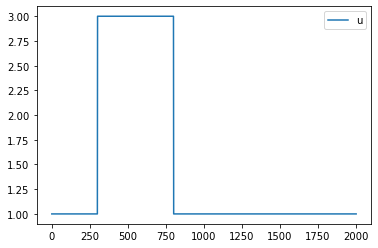

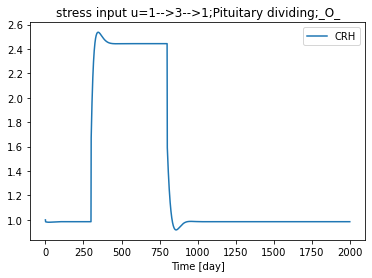

In [8]:
#step function pituitary dividing:
t_recovery=np.linspace(0, 2000, 3000)
plt.plot(t_recovery,[stress_input_a(x) for x in t_recovery])
plt.legend(['u'])
plt.figure()
sol_stress_recovery_dividing_o=odeint(lambda y,t: HPA_model_simulation_o_pituitary_dividing(y,t,timescale='day',u_func = stress_input_a),np.ones(5),t_recovery)
plt.plot(t_recovery,sol_stress_recovery_dividing_o[:,2])
plt.legend(['CRH','ACTH','Cortisol','pituitary','adrenal'])
plt.xlabel('Time [day]')
plt.title('stress input u=1-->3-->1;Pituitary dividing;_O_')
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.spines.top'] = False

Text(0.5, 1.0, 'stress input u=1-->3-->1;Pituitary nondividing;_O_')

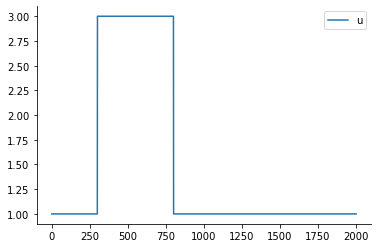

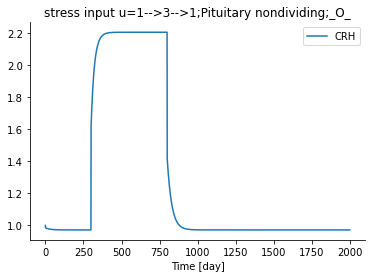

In [9]:
#step function pituitary nondividing:
t_recovery=np.linspace(0, 2000, 2000)
plt.plot(t_recovery,[stress_input_a(x) for x in t_recovery])
plt.legend(['u'])
plt.figure()
sol_stress_recovery_nondividing_o=odeint(lambda y,t: HPA_model_simulation_o_pituitary_nondividing(y,t,timescale='day',u_func = stress_input_a),np.ones(5),t_recovery)
plt.plot(t_recovery,sol_stress_recovery_nondividing_o[:,2])
plt.legend(['CRH','ACTH','Cortisol','pituitary','adrenal'])
plt.xlabel('Time [day]')
plt.title('stress input u=1-->3-->1;Pituitary nondividing;_O_')


Text(0.5, 1.0, 'stress input u=1-->3-->1;no pituitary;_O_')

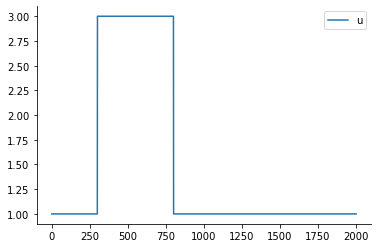

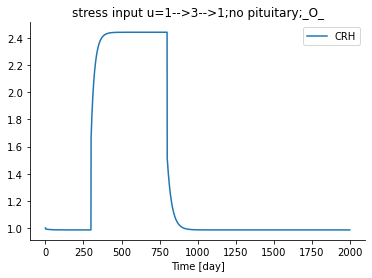

In [10]:
#step function no pituitary:
t_recovery=np.linspace(0, 2000, 2000)
plt.plot(t_recovery,[stress_input_a(x) for x in t_recovery])
plt.legend(['u'])
plt.figure()
sol_stress_recovery_no_pituitary_o=odeint(lambda y,t: HPA_model_simulation_o_no_pituitary_old(y,t,timescale='day',u_func = stress_input_a),np.ones(3),t_recovery)
plt.plot(t_recovery,sol_stress_recovery_no_pituitary_o[:,1])
plt.legend(['CRH','Cortisol','adrenal'])
plt.xlabel('Time [day]')
plt.title('stress input u=1-->3-->1;no pituitary;_O_')
#plt.ylim(0.4,1)

In [11]:
#simulating changing stress for no pit, pit nondividing and pit dividing: 

In [12]:
def stress_input_changing(t):
    if 0<t<50:
        return 1
    if 50<t<550:
        return 3
    if 550<t<600:
        return 1
    return 1

Text(0.5, 1.0, 'stress input changing;Pituitary dividing;_O_')

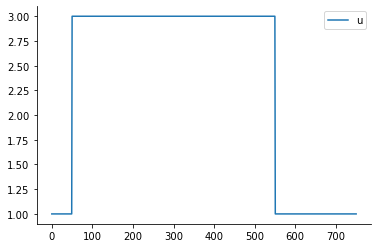

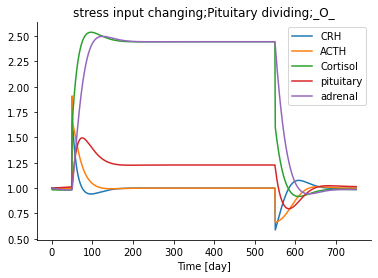

In [13]:
#changing stress pituitary dividing:
t_recovery=np.linspace(0, 750, 750)
plt.plot(t_recovery,[stress_input_changing(x) for x in t_recovery])
plt.legend(['u'])
plt.figure()
sol_stress_recovery_dividing_o_changing=odeint(lambda y,t: HPA_model_simulation_o_pituitary_dividing(y,t,timescale='day',u_func = stress_input_changing),np.ones(5),t_recovery)
plt.plot(t_recovery,sol_stress_recovery_dividing_o_changing)
plt.legend(['CRH','ACTH','Cortisol','pituitary','adrenal'])
plt.xlabel('Time [day]')
plt.title('stress input changing;Pituitary dividing;_O_')

Text(0.5, 1.0, 'stress input changing;Pituitary dividing;normalized')

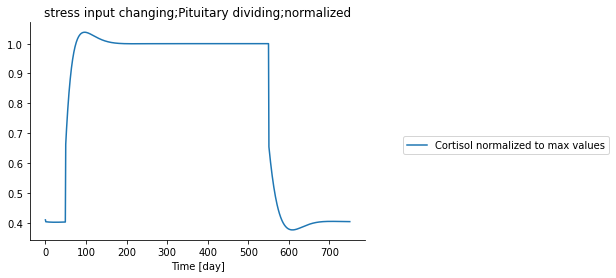

In [14]:
#normalizing cortisol for max values:
#cor=sol_stress_recovery_dividing_o_changing[:,2]
pitdividing_max=sol_stress_recovery_dividing_o_changing[:,2]/sol_stress_recovery_dividing_o_changing[549,2]
plt.plot(t_recovery,pitdividing_max)
plt.legend(['Cortisol normalized to max values'], bbox_to_anchor=[1.1, 0.5])
plt.xlabel('Time [day]')
plt.title('stress input changing;Pituitary dividing;normalized')

Text(0.5, 1.0, 'stress input changing;Pituitary dividing;normalized to min values')

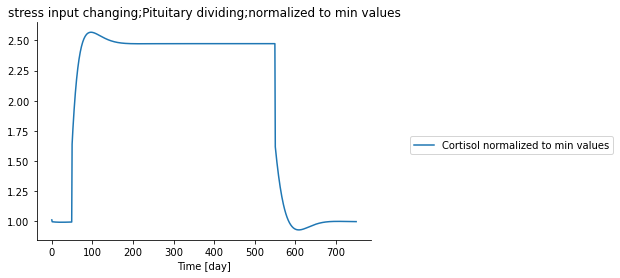

In [15]:
#normalizing cortisol for min values:
#def cort_min_stst(x3,t):
    #idx = t < 399
    #z = x3[idx][-1]
    #return z

#cor=sol_stress_recovery_dividing_o_changing[:,2]
pitdividing_min=sol_stress_recovery_dividing_o_changing[:,2]/sol_stress_recovery_dividing_o_changing[700,2]
plt.plot(t_recovery,pitdividing_min)
plt.legend(['Cortisol normalized to min values'], bbox_to_anchor=[1.1, 0.5])
plt.xlabel('Time [day]')
plt.title('stress input changing;Pituitary dividing;normalized to min values')

Text(0.5, 1.0, 'stress input changing;Pituitary dividing;normalized to 0-1')

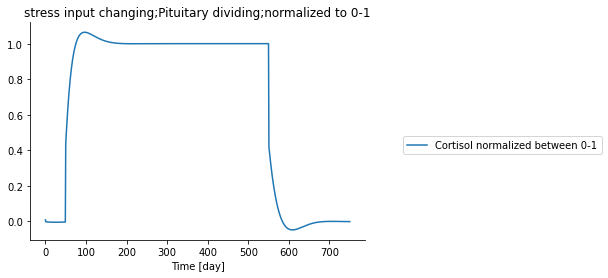

In [16]:
#normalizing cortisol to be between 0-1:
pit_dividing_zero_one=(sol_stress_recovery_dividing_o_changing[:,2]-sol_stress_recovery_dividing_o_changing[700,2])/(sol_stress_recovery_dividing_o_changing[549,2]-sol_stress_recovery_dividing_o_changing[700,2])
plt.plot(t_recovery,pit_dividing_zero_one)
plt.legend(['Cortisol normalized between 0-1'], bbox_to_anchor=[1.1, 0.5])
plt.xlabel('Time [day]')
plt.title('stress input changing;Pituitary dividing;normalized to 0-1')


#zi = (xi – min(x)) / (max(x) – min(x))

In [17]:
###calculating rise time, settling time and response time for pituitary dividing:

In [18]:
###code not relvant since I changed the input. I left it so if it will be needed I can revive it in this notebook
## (with the correct indexes)

In [19]:
#calculating rise time (time for reaching 90% from max value for the first time)
#np.where([r1>=0.9 for r1 in pit_dividing_zero_one])

In [20]:
#calculating settling time (time for reaching 95%-105% from steady state after inserting step input):
#np.where([r2>=0.95 and r2<=1.05 for r2 in pit_dividing_zero_one])

In [21]:
#calculating response time (time for reaching 50% max value after removing the input=t1/2):
#pit_dividing_zero_one[801]

In [22]:
###stopped here 11/05/23

Text(0.5, 1.0, 'stress input changing;Pituitary nondividing;_O_')

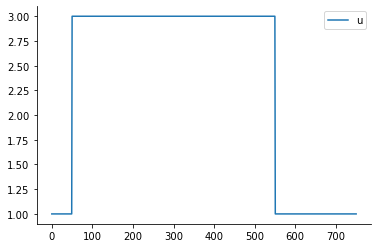

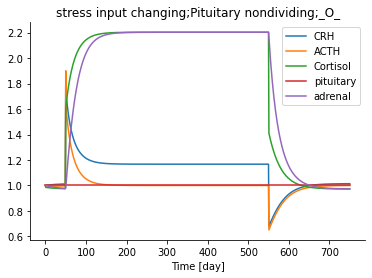

In [23]:
#changing stress pituitary nondividing:
t_recovery=np.linspace(0, 750, 750)
plt.plot(t_recovery,[stress_input_changing(x) for x in t_recovery])
plt.legend(['u'])
plt.figure()
sol_stress_recovery_nondividing_o_changing=odeint(lambda y,t: HPA_model_simulation_o_pituitary_nondividing(y,t,timescale='day',u_func = stress_input_changing),np.ones(5),t_recovery)
plt.plot(t_recovery,sol_stress_recovery_nondividing_o_changing)
plt.legend(['CRH','ACTH','Cortisol','pituitary','adrenal'])
plt.xlabel('Time [day]')
plt.title('stress input changing;Pituitary nondividing;_O_')

Text(0.5, 1.0, 'stress input changing;Pituitary nondividing;normalized to max values')

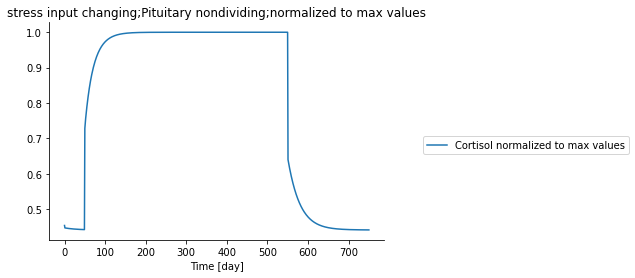

In [24]:
#normalizing cortisol for max values:
pit_non_dividing=sol_stress_recovery_nondividing_o_changing[:,2]/sol_stress_recovery_nondividing_o_changing[549,2]
plt.plot(t_recovery,pit_non_dividing)
plt.legend(['Cortisol normalized to max values'], bbox_to_anchor=[1.1, 0.5])
plt.xlabel('Time [day]')
plt.title('stress input changing;Pituitary nondividing;normalized to max values')

Text(0.5, 1.0, 'stress input changing;Pituitary nondividing;normalized to min')

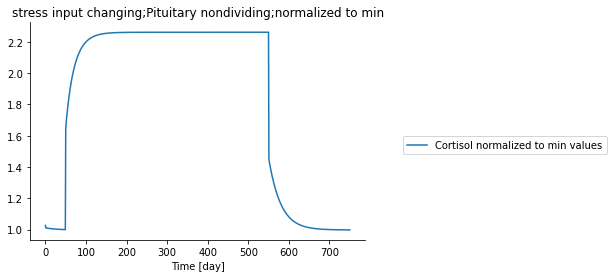

In [25]:
#normalizing cortisol for min values:
pit_non_dividing_min=sol_stress_recovery_nondividing_o_changing[:,2]/sol_stress_recovery_nondividing_o_changing[700,2]
plt.plot(t_recovery,pit_non_dividing_min)
plt.legend(['Cortisol normalized to min values'], bbox_to_anchor=[1.1, 0.5])
plt.xlabel('Time [day]')
plt.title('stress input changing;Pituitary nondividing;normalized to min')

Text(0.5, 1.0, 'stress input changing;Pituitary non dividing;normalized to 0-1')

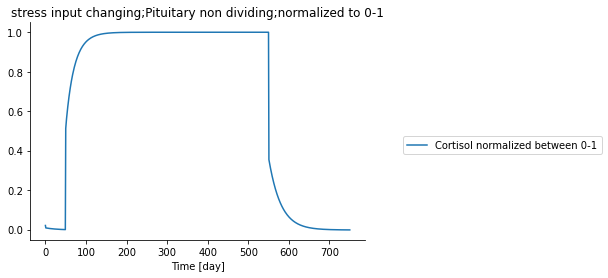

In [26]:
#normalizing cortisol to be between 0-1:
pit_non_dividing_zero_one=(sol_stress_recovery_nondividing_o_changing[:,2]-sol_stress_recovery_nondividing_o_changing[700,2])/(sol_stress_recovery_nondividing_o_changing[549,2]-sol_stress_recovery_nondividing_o_changing[700,2])
plt.plot(t_recovery,pit_non_dividing_zero_one)
plt.legend(['Cortisol normalized between 0-1'], bbox_to_anchor=[1.1, 0.5])
plt.xlabel('Time [day]')
plt.title('stress input changing;Pituitary non dividing;normalized to 0-1')


#zi = (xi – min(x)) / (max(x) – min(x))

In [27]:
###code not relvant since I changed the input. I left it so if it will be needed I can revive it in this notebook
## (with the correct indexes)

In [28]:
###calculating rise time and response time for pituitary nondividing:
#calculating rise time (time for reaching 90% from max value for the first time)
#np.where([v>=0.9 for v in pit_non_dividing_zero_one])

In [29]:
#response time:
#pit_non_dividing_zero_one[801]

Text(0.5, 1.0, 'stress input changing;no Pituitary;_O_')

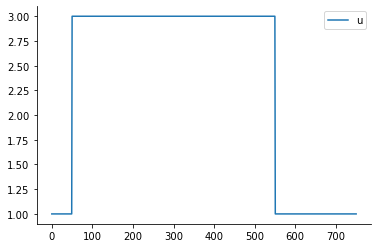

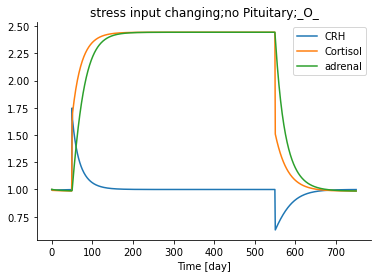

In [30]:
#changing stress no pituitary:
t_recovery=np.linspace(0, 750, 750)
plt.plot(t_recovery,[stress_input_changing(x) for x in t_recovery])
plt.legend(['u'])
plt.figure()
sol_stress_recovery_no_pituitary_o_changing=odeint(lambda y,t: HPA_model_simulation_o_no_pituitary_old(y,t,timescale='day',u_func = stress_input_changing),np.ones(3),t_recovery)
plt.plot(t_recovery,sol_stress_recovery_no_pituitary_o_changing)
plt.legend(['CRH','Cortisol','adrenal'])
plt.xlabel('Time [day]')
plt.title('stress input changing;no Pituitary;_O_')

Text(0.5, 1.0, 'stress input changing;no Pituitary;normalized to max values')

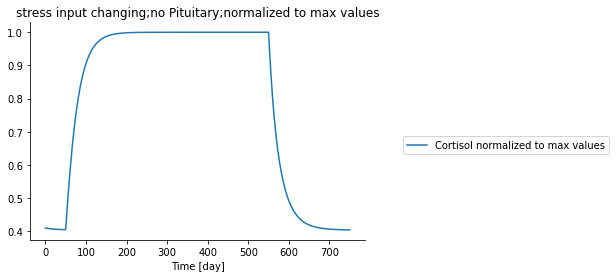

In [31]:
#normalizing cortisol for max values:
no_pit=sol_stress_recovery_no_pituitary_o_changing[:,2]/sol_stress_recovery_no_pituitary_o_changing[549,2]
plt.plot(t_recovery,no_pit)
plt.legend(['Cortisol normalized to max values'], bbox_to_anchor=[1.1, 0.5])
plt.xlabel('Time [day]')
plt.title('stress input changing;no Pituitary;normalized to max values')

Text(0.5, 1.0, 'stress input changing;no Pituitary;normalized to min')

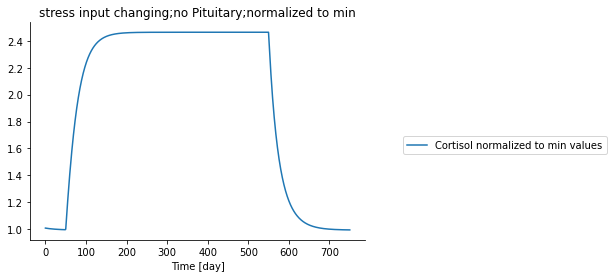

In [32]:
#normalizing cortisol for min values:
no_pit_min=sol_stress_recovery_no_pituitary_o_changing[:,2]/sol_stress_recovery_no_pituitary_o_changing[700,2]
plt.plot(t_recovery,no_pit_min)
plt.legend(['Cortisol normalized to min values'], bbox_to_anchor=[1.1, 0.5])
plt.xlabel('Time [day]')
plt.title('stress input changing;no Pituitary;normalized to min')

Text(0.5, 1.0, 'stress input changing;no Pituitary;normalized to 0-1')

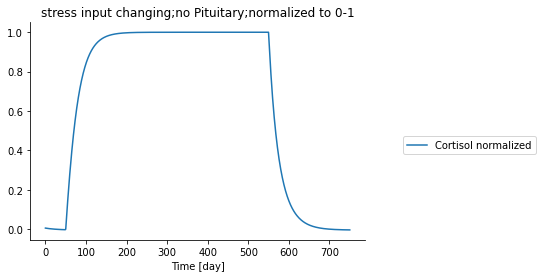

In [33]:
#normalizing cortisol to be between 0-1:
no_pit_zero_one=(sol_stress_recovery_no_pituitary_o_changing[:,2]-sol_stress_recovery_no_pituitary_o_changing[700,2])/(sol_stress_recovery_no_pituitary_o_changing[549,2]-sol_stress_recovery_no_pituitary_o_changing[700,2])
plt.plot(t_recovery,no_pit_zero_one)
plt.legend(['Cortisol normalized'], bbox_to_anchor=[1.1, 0.5])
plt.xlabel('Time [day]')
plt.title('stress input changing;no Pituitary;normalized to 0-1')


#zi = (xi – min(x)) / (max(x) – min(x))

In [34]:
###code not relvant since I changed the input. I left it so if it will be needed I can revive it in this notebook
## (with the correct indexes)

In [35]:
###calculating rise time and response time for no pituitary (circuit 4):
#calculating rise time (time for reaching 90% from max value for the first time)
#np.where([l>=0.9 for l in no_pit_zero_one])

In [36]:
#calculating response time:
#np.where([l2>=0.45 and l2<=0.55 for l2 in no_pit_zero_one])

(0.0, 1.2)

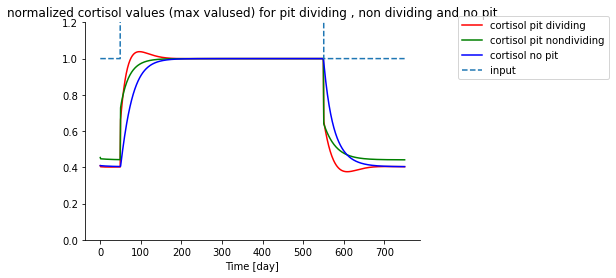

In [37]:
#comparing normalized cortisol values (to max) for pit dividing, no dividing, and no pituitary:
plt.figure()
plt.plot(t_recovery,pitdividing_max,color='red')
plt.plot(t_recovery,pit_non_dividing,color='green')
plt.plot(t_recovery,no_pit,color='blue')
plt.plot(t_recovery,[stress_input_changing(x) for x in t_recovery],'--')
plt.xlabel('Time [day]')
plt.legend(['cortisol pit dividing' , 'cortisol pit nondividing' , 'cortisol no pit' , 'input'], bbox_to_anchor=(1.1, 1.05))
plt.title('normalized cortisol values (max valused) for pit dividing , non dividing and no pit')
plt.ylim(0,1.2)

Text(0.5, 1.0, 'normalized cortisol values (min values) for pit dividing , non dividing and no pit')

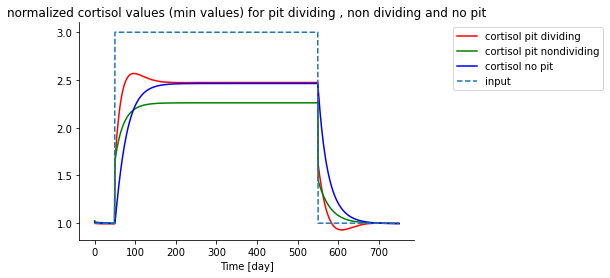

In [38]:
#comparing normalized cortisol values (to min) for pit dividing, no dividing, and no pituitary:
plt.figure()
plt.plot(t_recovery,pitdividing_min,color='red')
plt.plot(t_recovery,pit_non_dividing_min,color='green')
plt.plot(t_recovery,no_pit_min,color='blue')
plt.plot(t_recovery,[stress_input_changing(x) for x in t_recovery],'--')
plt.xlabel('Time [day]')
plt.legend(['cortisol pit dividing' , 'cortisol pit nondividing' , 'cortisol no pit' , 'input'], bbox_to_anchor=(1.1, 1.0))
plt.title('normalized cortisol values (min values) for pit dividing , non dividing and no pit')
#plt.ylim(0,3)

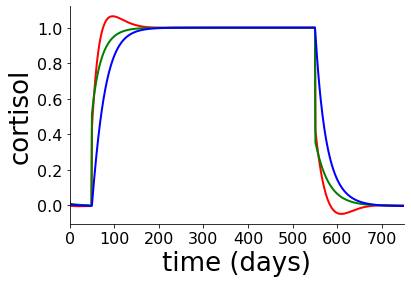

In [67]:
#comparing normalized cortisol values (0-1) for pit dividing, no dividing, and no pituitary:
plt.figure()
plt.plot(t_recovery,pit_dividing_zero_one,color='red',linewidth='2')
plt.plot(t_recovery,pit_non_dividing_zero_one,color='green',linewidth='2')
plt.plot(t_recovery,no_pit_zero_one,color='blue',linewidth='2')
#plt.plot(t_recovery,[stress_input_changing(x) for x in t_recovery],'--')
plt.xlabel('time (days)',fontsize=26)
#plt.legend(['HPA axis' , 'Alternative with constant pituitary (class 4 circuit)' , 'Alternative without pituitary'], bbox_to_anchor=(0.9, 1.0))
#plt.title('normalized cortisol values (0-1) for pituitary dividing, pituitary mass constant and no pituitary')
plt.ylabel('cortisol',fontsize=26)
#plt.ylim(-0.25,1.25)
plt.xlim(0,750)
#plt.rcParams['axes.linewidth'] = 2
#plt.tick_params(width=2)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.savefig("comparing-pituitary.svg", bbox_inches='tight', transparent=True)

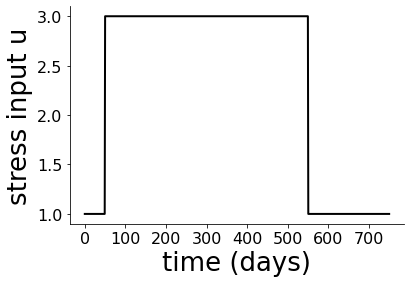

In [68]:
plt.plot(t_recovery,[stress_input_changing(x) for x in t_recovery],linewidth='2', color='black')
#plt.tick_params(width=2)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.ylabel('stress input u',fontsize=26)
plt.xlabel('time (days)',fontsize=26)
#plt.xlim(0,700)
#plt.ylim(0,3)
plt.xticks(fontsize=16)
plt.yticks([1.0,1.5,2.0,2.5,3.0],fontsize=16)
plt.savefig("comparing-pituitary-input.svg", transparent=True)

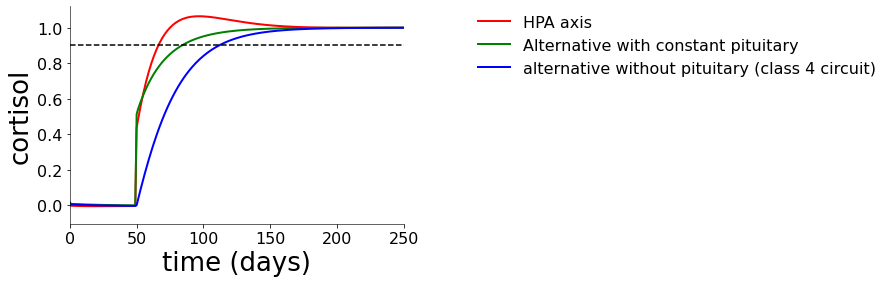

In [130]:
#comparing normalized cortisol values (0-1) for pit dividing, no dividing, and no pituitary:
plt.figure()
plt.plot(t_recovery,pit_dividing_zero_one,color='red',linewidth='2')
plt.plot(t_recovery,pit_non_dividing_zero_one,color='green',linewidth='2')
plt.plot(t_recovery,no_pit_zero_one,color='blue',linewidth='2')
#plt.plot(t_recovery,[stress_input_changing(x) for x in t_recovery],'--')
#plt.legend(['HPA axis' , 'Alternative with constant pituitary (class 4 circuit)' , 'Alternative without pituitary'], bbox_to_anchor=(0.9, 1.0))
#plt.legend(['HPA axis' , 'Alternative with constant pituitary (class 4 circuit)' , 'Alternative without pituitary'], bbox_to_anchor=(1.2, 0.9))                                                                                                                                   
#plt.title('normalized cortisol values (0-1) for pituitary dividing , pituitary mass constant and no pituitary')
plt.ylabel('cortisol')
plt.xlim(0,250)
#plt.tick_params(width=2)
plt.rcParams['axes.linewidth'] = 0.6
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.ylabel('cortisol',fontsize=26)
plt.xlabel('time (days)',fontsize=26)
plt.axhline(y=0.9, color='black', linestyle='--')
plt.legend(['HPA axis' , 'Alternative with constant pituitary' , 'alternative without pituitary (class 4 circuit)'],
            frameon=False , loc=(1.2,0.65) , fontsize=16)
plt.savefig("comparing-pituitary-zoomin.svg", bbox_inches='tight', transparent=True)

In [131]:
#########14.02.24#########